### Setup and imports

In [16]:
import pandas as pd
import numpy as np
import rdkit
import ast
import matplotlib.pyplot as plt
#add future imports here

In [17]:
df = pd.read_csv(r"C:\CSC 4444\project\dataset\Labelled_SMILES_IR_Spectroscopy.csv", low_memory=False)

In [18]:
def plot_graph(row):
    x_coords = row["x_coords"]
    y_coords = row["y_coords"]

    if isinstance(x_coords, str):
        x_coords = ast.literal_eval(x_coords)
    if isinstance(y_coords, str):
        y_coords = ast.literal_eval(y_coords)

    plt.figure(figsize=(10, 4))
    plt.plot(x_coords, y_coords, linewidth=1)
    plt.xlabel("1/cm")
    plt.ylabel("Absorbance")
    plt.title(row.get("smiles", "IR Spectrum"))
    plt.tight_layout()
    plt.show()
    return None

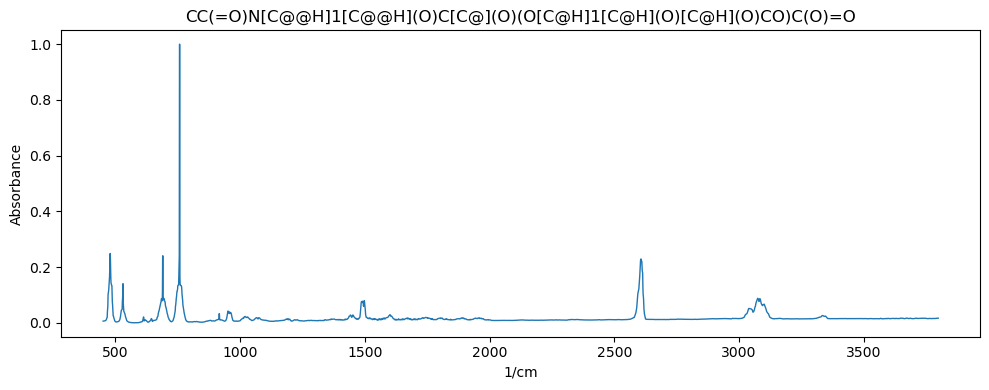

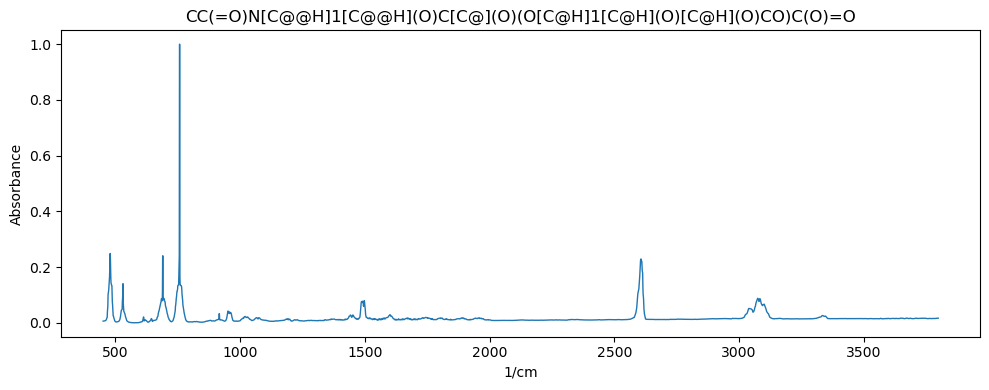

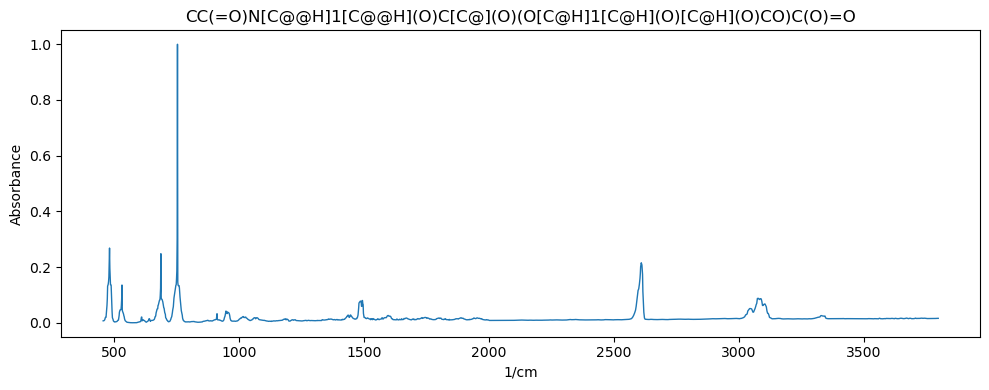

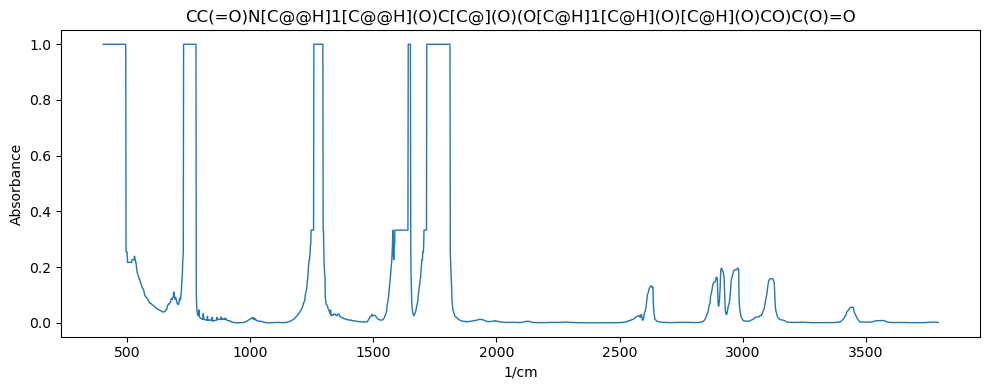

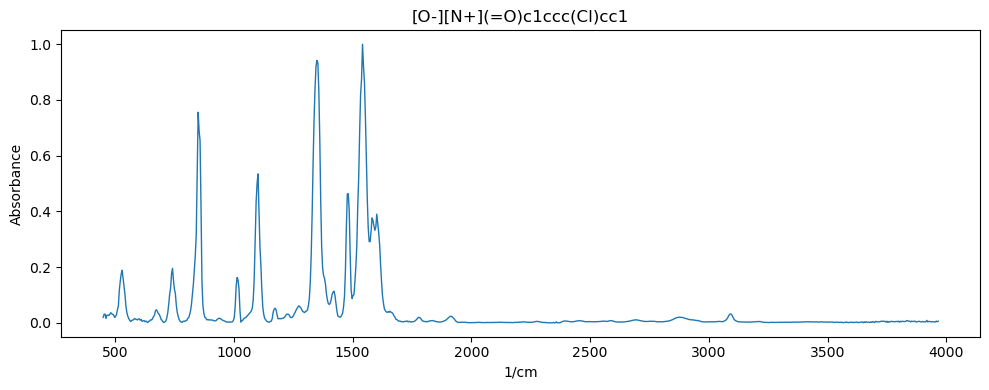

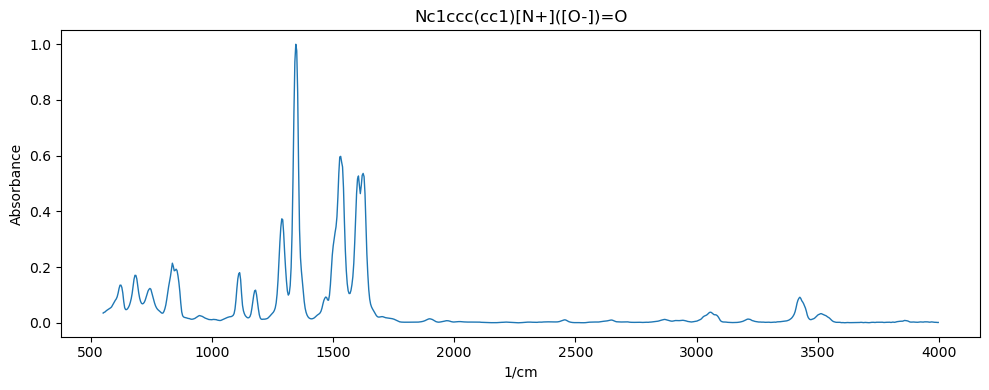

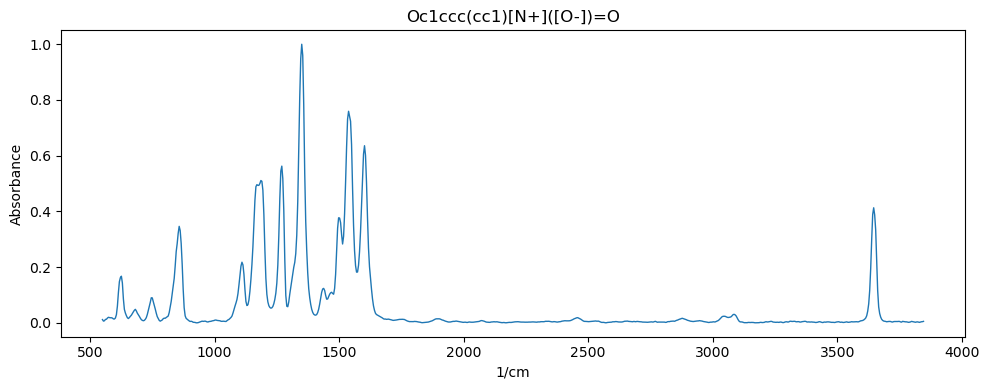

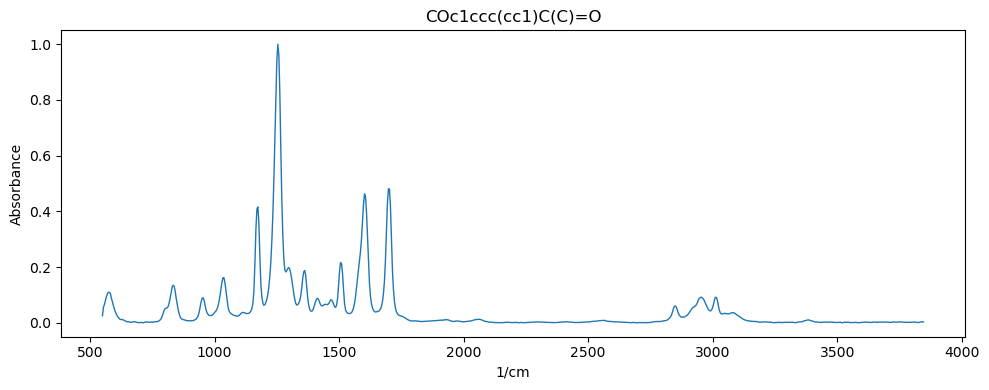

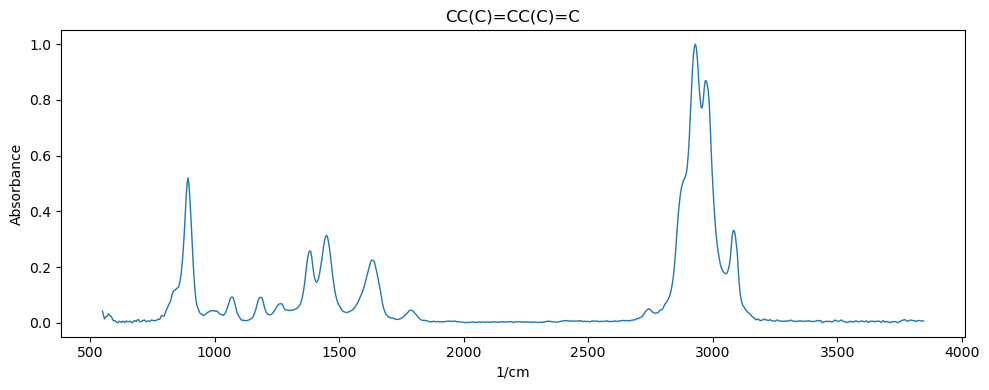

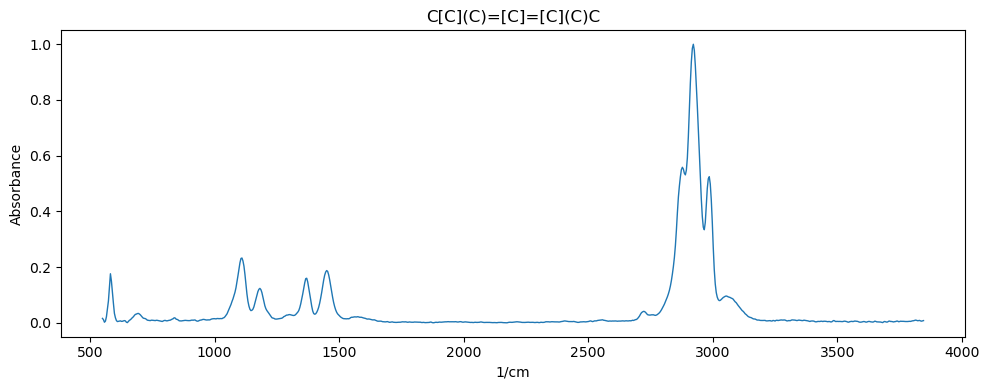

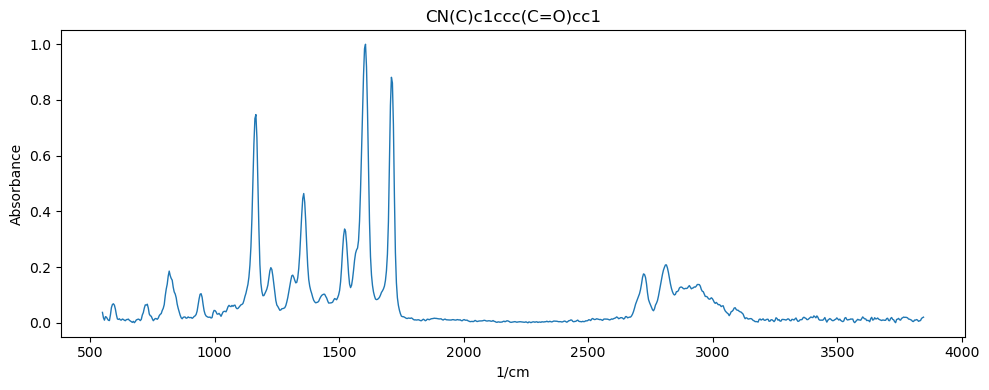

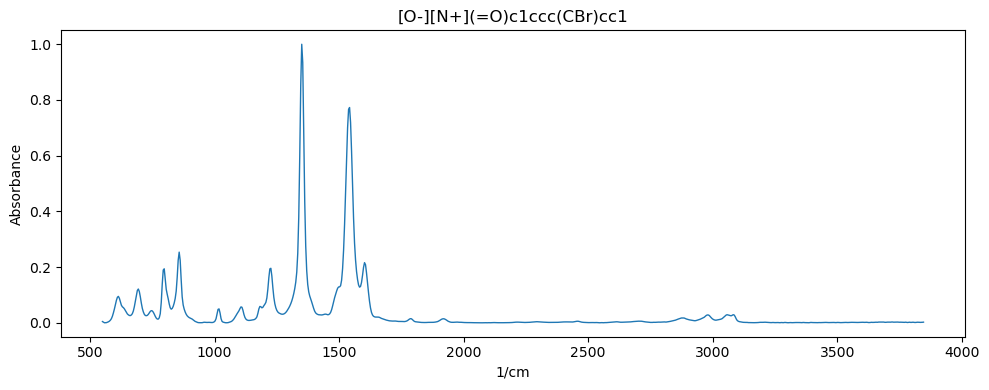

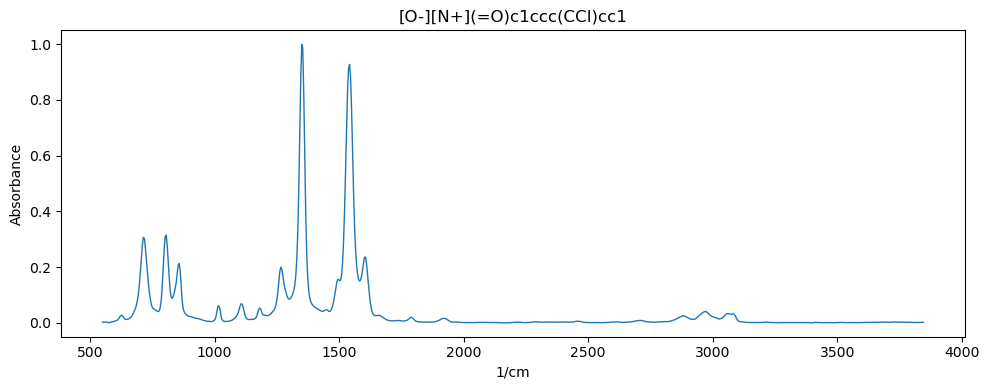

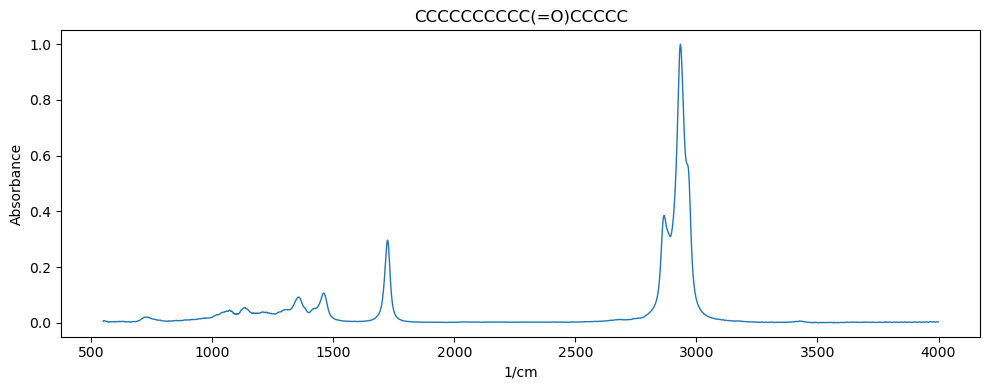

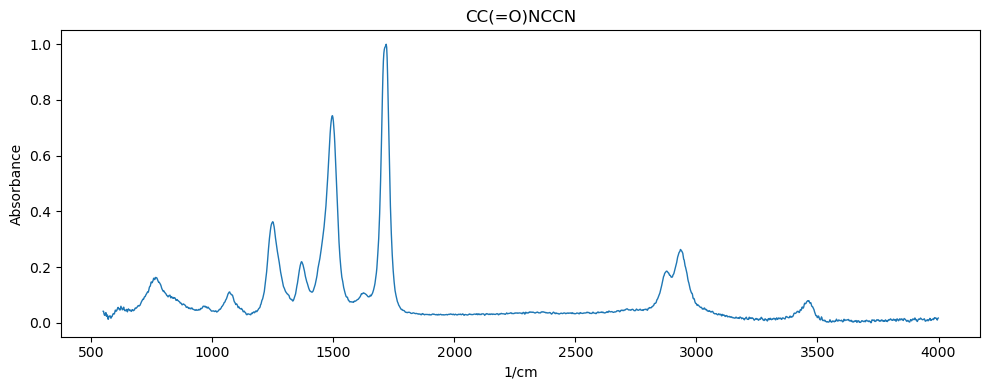

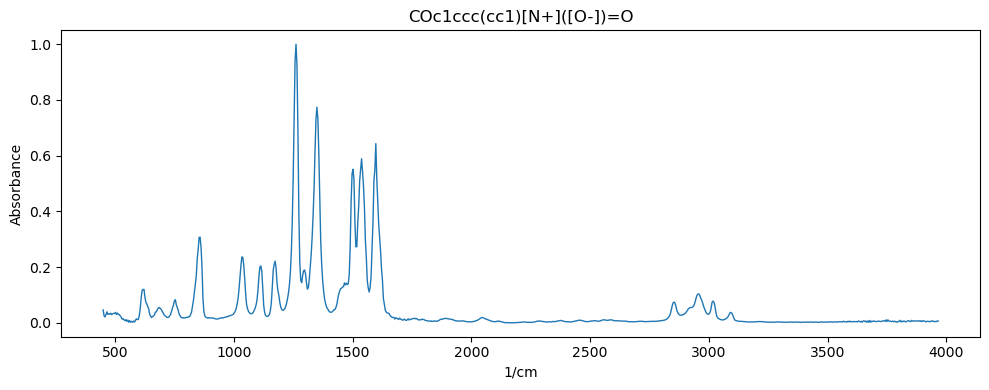

In [19]:
#test it
plot_graph(df.iloc[0])
for i in range(15):
    print("================")
    plot_graph(df.iloc[i])

## Normalization of data

### Standardize spectra through interpolating coordinate data to fixed grid 
* Using indiviail based normalizaiton and not group global normalization because:
  * experimental conditions may not have been consistant
  * the model learns scale artifacts (instrument, concentration) which makes it worse at generalization

In [20]:
#temp. perform normalization on small sample of data for computation
test_df = df.sample(500)

In [21]:
#perform 


## Labeling

### Canonicallize smiles 
* learn more at 
  * https://luis-vollmers.medium.com/tutorial-to-smiles-and-canonical-smiles-explained-with-examples-fbc8a46ca29f
  * could be done via rdkit

### Create Labels 

### Generate fingerprint targets

## Data Splitting

### Train / Validation / Test Split

## Baseline Modeling

### Build Simple 1D CNN Baseline
* subjet to change

### Compare Against Classical Baseline

## Main Model

### Build CNN with Multi-Task Outputs

### Train the Model

## Evaluation
* for results section

### Evaluate Functional Group Prediction (F1, Precision, Recall)

### Evaluate Retrieval Performance (Top-K Accuracy, MRR)

### Calibration and Confidence Analysis

## Deployment Design

### Functional Group Probability Outputs

### Top-K SMILES Candidate Retrieval

### Confidence and Uncertainty Display

In [22]:
#Smiles canonicalization implementation
from rdkit import Chem

def canonicalize_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        return Chem.MolToSmiles(mol)
    except:
        return None

df['canonical_smiles'] = df['smiles'].apply(canonicalize_smiles)

print(f"Total rows: {len(df)}")
print(f"Successfully canonicalized: {df['canonical_smiles'].notna().sum()}")

df.to_csv(r"C:\CSC 4444\project\dataset\SMILES_IR_Spectroscopy.csv", index=False)
print("Dataset updated.")

print(df.columns.tolist())
df[['smiles', 'canonical_smiles']]

Total rows: 7910
Successfully canonicalized: 7910
Dataset updated.
['filename', 'smiles', 'origin_xunits', 'origin_yunits', 'x_coords', 'y_coords', 'canonical_smiles', 'y_min_before_minmax', 'y_max_before_minmax', 'y_range_before_minmax', 'y_normalization', 'bead_summary']


,smiles,canonical_smiles
0,CC(=O)N[C@@H]1[C@@H](O)C[C@](O)(O[C@H]1[C@H](O...,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)O[C@](O)...
1,CC(=O)N[C@@H]1[C@@H](O)C[C@](O)(O[C@H]1[C@H](O...,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)O[C@](O)...
2,CC(=O)N[C@@H]1[C@@H](O)C[C@](O)(O[C@H]1[C@H](O...,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)O[C@](O)...
3,[O-][N+](=O)c1ccc(Cl)cc1,O=[N+]([O-])c1ccc(Cl)cc1
4,Nc1ccc(cc1)[N+]([O-])=O,Nc1ccc([N+](=O)[O-])cc1
...,...,...
7905,CCOC(=O)c1ccccc1N=C=S,CCOC(=O)c1ccccc1N=C=S
7906,OC(=O)c1ccc(O)cc1,O=C(O)c1ccc(O)cc1
7907,CC#CC(C)(C)C,CC#CC(C)(C)C
7908,CN(C)c1ccc(C)cc1,Cc1ccc(N(C)C)cc1


In [23]:
print(df.columns.tolist())

['filename', 'smiles', 'origin_xunits', 'origin_yunits', 'x_coords', 'y_coords', 'canonical_smiles', 'y_min_before_minmax', 'y_max_before_minmax', 'y_range_before_minmax', 'y_normalization', 'bead_summary']


In [25]:
df[['canonical_smiles', 'bead_summary']].head(10)

,canonical_smiles,bead_summary
0,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)O[C@](O)...,"P3, N6, N4, P4, P1, N6, P2"
1,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)O[C@](O)...,"P3, N6, N4, P4, P1, N6, P2"
2,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)O[C@](O)...,"P3, N6, N4, P4, P1, N6, P2"
3,O=[N+]([O-])c1ccc(Cl)cc1,"N3, C5, X3, C5"
4,Nc1ccc([N+](=O)[O-])cc1,"N6, C5, N3, C5"
5,O=[N+]([O-])c1ccc(O)cc1,"N3, C5, N6, C5"
6,COc1ccc(C(C)=O)cc1,"N2, C5, C5, N4, C5"
7,C=C(C)C=C(C)C,"C4, C4"
8,CC(C)=C=C(C)C,"C2, C4"
9,CN(C)c1ccc(C=O)cc1,"N1, C5, C5, N4, C5"


In [28]:
from sklearn.preprocessing import MultiLabelBinarizer

df['bead_list'] = df['bead_summary'].apply(lambda x: [b.strip() for b in x.split(',')] if isinstance(x, str) else [])

mlb = MultiLabelBinarizer()
bead_labels = mlb.fit_transform(df['bead_list'])

print(f"Number of unique bead types: {len(mlb.classes_)}")
print(f"Bead types: {mlb.classes_}")
print(f"Label matrix shape: {bead_labels.shape}")

Number of unique bead types: 23
Bead types: ['C1' 'C2' 'C3' 'C4' 'C5' 'C6' 'N1' 'N2' 'N3' 'N4' 'N5' 'N6' 'P1' 'P2'
 'P3' 'P4' 'P5' 'P6' 'Q4' 'X1' 'X2' 'X3' 'X4']
Label matrix shape: (7910, 23)


In [29]:
from scipy.interpolate import interp1d
import ast

def interpolate_spectrum(row,target_length=3600):
    x = ast.literal_eval(row['x_coords']) if isinstance(row['x_coords'], str) else row['x_coords']
    y = ast.literal_eval(row['y_coords']) if isinstance(row['y_coords'], str) else row['y_coords']
    f = interp1d(x, y, bounds_error=False, fill_value=0)
    x_new = np.linspace(400, 4000, target_length)
    return f(x_new)
    
spectra = np.array([interpolate_spectrum(row) for _, row in df.iterrows()])
print(f"Spectra shape: {spectra.shape}")

Spectra shape: (7910, 3600)


In [31]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

X = torch.tensor(spectra, dtype=torch.float32).unsqueeze(1)  
y = torch.tensor(bead_labels, dtype=torch.float32)           # Shape: (7910, 23)

# Train/test split
dataset = TensorDataset(X, y)
train_size = int(0.8 * len(dataset)) #train sample size would be 80% of the dataset
test_size = len(dataset) - train_size #test sample size would be 20% of the dataset
train_set, test_set = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
test_loader = DataLoader(test_set, batch_size=32)

print(f"Training samples: {train_size}")
print(f"Test samples: {test_size}")


Training samples: 6328
Test samples: 1582


In [32]:
class IRBeadClassifier(nn.Module):
    def __init__(self, input_length, num_bead_types):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )
        conv_output_size = 128 * (input_length // 8)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(conv_output_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_bead_types),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv_layers(x)
        return self.classifier(x)

model = IRBeadClassifier(input_length=3600, num_bead_types=23)
print(model)


IRBeadClassifier(
  (conv_layers): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=57600, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=23, bias=True)
    (5): Sigmoid()
  )
)


In [35]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training loop
num_epochs = 30
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f}")


Epoch 1/30 | Loss: 0.0787
Epoch 2/30 | Loss: 0.0726
Epoch 3/30 | Loss: 0.0694
Epoch 4/30 | Loss: 0.0685
Epoch 5/30 | Loss: 0.0659
Epoch 6/30 | Loss: 0.0640
Epoch 7/30 | Loss: 0.0613
Epoch 8/30 | Loss: 0.0599
Epoch 9/30 | Loss: 0.0570
Epoch 10/30 | Loss: 0.0558
Epoch 11/30 | Loss: 0.0551
Epoch 12/30 | Loss: 0.0524
Epoch 13/30 | Loss: 0.0532
Epoch 14/30 | Loss: 0.0515
Epoch 15/30 | Loss: 0.0506
Epoch 16/30 | Loss: 0.0483
Epoch 17/30 | Loss: 0.0480
Epoch 18/30 | Loss: 0.0462
Epoch 19/30 | Loss: 0.0454
Epoch 20/30 | Loss: 0.0443
Epoch 21/30 | Loss: 0.0434
Epoch 22/30 | Loss: 0.0436
Epoch 23/30 | Loss: 0.0425
Epoch 24/30 | Loss: 0.0406
Epoch 25/30 | Loss: 0.0417
Epoch 26/30 | Loss: 0.0397
Epoch 27/30 | Loss: 0.0391
Epoch 28/30 | Loss: 0.0387
Epoch 29/30 | Loss: 0.0383
Epoch 30/30 | Loss: 0.0387


In [36]:
from sklearn.metrics import hamming_loss, f1_score

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch)
        preds_binary = (preds > 0.5).float()
        all_preds.append(preds_binary.numpy())
        all_labels.append(y_batch.numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

print(f"Hamming Loss: {hamming_loss(all_labels, all_preds):.4f}")
print(f"F1 Score: {f1_score(all_labels, all_preds, average='micro'):.4f}")
print(f"Match Accuracy: {(all_preds == all_labels).all(axis=1).mean():.4f}")


Hamming Loss: 0.0535
F1 Score: 0.7536
Match Accuracy: 0.3224


In [37]:
torch.save(model.state_dict(), "ir_bead_classifier.pth")
print("Save successful")

Save successful
